In [85]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import StandardScaler

In [86]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [87]:
# Need to choose patient_id from OUS_D2 in response_OUS
data = list(OUS_D2['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D2 with response_OUS
clinical_train = pd.merge(OUS_D2, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [88]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [89]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [90]:
(MAASTRO_D2['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [91]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [92]:
# need to choose patient_id from MAASTRO_D2 in response_MAASTRO
data = list(MAASTRO_D2['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [93]:
# Merge MAASTRO_D2 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D2, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,0.765178,0.610062,30.504395,50.002093,52.886671,58.000000,47.759816,58.864251,38067.208333,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,0.776540,0.504616,21.069386,41.753334,44.922155,44.294469,44.147480,48.723711,17870.791667,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,0.697164,0.478604,21.238275,44.375483,48.466483,45.891176,37.656341,48.969378,17426.500000,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,0.574636,0.446059,20.570459,46.115989,42.544095,47.507894,33.837849,55.226805,12463.791667,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,0.633419,0.480378,26.130155,54.394967,66.030296,56.320511,45.398238,67.089492,28300.125000,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,0.882411,0.577884,19.774388,34.218615,41.785165,40.261644,35.805028,43.520110,12822.458333,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,0.535802,0.455642,23.259099,51.046869,51.264022,51.264022,33.600595,52.440442,18368.291667,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,0.716610,0.631485,31.838169,50.417953,46.324939,56.035703,57.070132,57.671483,35384.541667,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,0.665145,0.628338,28.213278,44.901412,50.289164,50.596443,35.777088,51.478151,26180.208333,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [94]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [95]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [96]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [97]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [98]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 374)
y_train:  (139,)


In [99]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [100]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 376)

# Standardization for Clustering

In [101]:
original_X = X.copy()

In [102]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = StandardScaler()  
X_std = StandardScaler().fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [103]:
X_std

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_003_PET,LBP_012_PET,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET
0,-0.681983,0.072232,-0.022147,-0.098422,-0.064869,-0.154963,-0.351051,-0.205326,-0.264072,-0.404946,...,0.219845,-0.421688,-0.407611,0.649193,-0.562251,-0.485901,-0.476493,-0.315438,-0.628430,-0.413296
1,1.006304,-1.302158,-1.424304,-1.209119,-1.167748,-1.275109,-0.883607,-1.196220,-0.663487,-0.804734,...,1.527450,2.223783,0.815169,-1.567292,-0.562251,2.201059,1.084993,1.967842,1.565306,0.413103
2,0.523938,0.584632,0.622463,0.280542,0.451165,0.168246,0.227903,0.449566,0.117578,0.630836,...,-0.494051,-0.206168,-0.017635,0.728066,-0.202838,-0.292141,-0.900502,-0.805067,-0.716683,-0.302865
3,1.049432,-0.986261,-1.284222,-1.147026,-1.233102,-1.350955,-0.556796,-0.966118,-0.649352,-0.719083,...,1.240309,1.677006,0.872919,-1.385502,-0.562251,0.020087,1.125919,-0.805067,0.825461,0.917326
4,0.935477,-0.686277,-0.768038,-0.568449,-0.838469,-0.503670,-0.397572,-0.585393,-0.599652,-0.093676,...,-0.494051,-0.120491,0.768381,-1.787743,1.514080,2.295595,1.423898,2.359078,2.627010,2.164951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-0.125182,-0.022089,-0.563023,-0.671191,-0.597238,-0.528508,-0.796924,-0.702160,-0.500356,-0.648734,...,-0.494051,-0.278432,-0.429414,0.422155,-0.562251,-0.723888,-0.097562,-0.805067,-0.670464,-0.437236
135,0.421312,1.711257,0.776091,-0.163918,0.111108,0.238540,0.089609,0.057012,0.010885,0.105783,...,-0.266222,-0.129499,0.269550,0.163495,-0.562251,0.340120,-0.400566,-0.180035,-0.330996,0.240232
136,0.504939,0.995873,0.104368,-0.445412,-0.720746,-0.262816,0.239847,-0.442112,-0.290613,-0.149611,...,-0.494051,-0.731873,-0.968902,0.980469,-0.562251,-0.935904,-0.468144,-0.805067,-0.768158,-0.030746
137,-0.485754,-0.279046,-0.015696,0.143137,0.007743,-0.062119,-0.191452,0.010924,-0.197257,-0.092981,...,-0.494051,-0.473789,-0.042353,0.070429,-0.562251,-0.041198,0.025938,-0.374777,-0.303401,0.428295


# Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

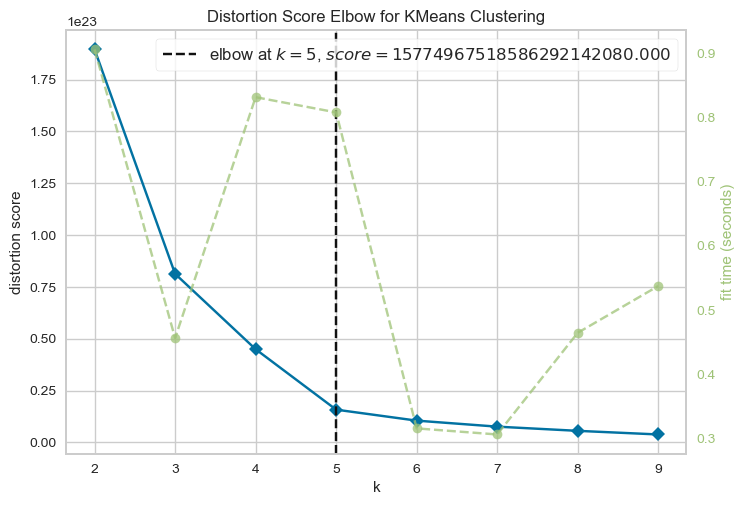

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [104]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [105]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=5)

0
Most correlated column: gldm_DependenceNonUniformityNormalized_d_1_CT_b20
Correlation coefficient: 1.0072463768115951


1
Most correlated column: glszm_SizeZoneNonUniformity_PET_b2
Correlation coefficient: 1.0072463768115953


2
Most correlated column: glcm_MCC_d_1_CT_b20
Correlation coefficient: 1.0072463768115953


3
Most correlated column: gldm_DependenceVariance_d_1_CT_b20
Correlation coefficient: 1.007246376811595


4
Most correlated column: glszm_HighGrayLevelZoneEmphasis_PET_c04
Correlation coefficient: 1.0072463768115953




In [106]:
selected_features

['gldm_DependenceNonUniformityNormalized_d_1_CT_b20',
 'glszm_SizeZoneNonUniformity_PET_b2',
 'glcm_MCC_d_1_CT_b20',
 'gldm_DependenceVariance_d_1_CT_b20',
 'glszm_HighGrayLevelZoneEmphasis_PET_c04']

In [107]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [108]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = StandardScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [109]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns

MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [110]:
X_new

,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,glszm_SizeZoneNonUniformity_PET_b2,glcm_MCC_d_1_CT_b20,gldm_DependenceVariance_d_1_CT_b20,glszm_HighGrayLevelZoneEmphasis_PET_c04
0,0.055238,3.470588,0.817715,32.025998,20.909091
1,0.050688,1.250000,0.773956,35.942044,17.583333
2,0.048612,1.600000,0.810414,33.209993,13.000000
3,0.077182,1.000000,0.710132,15.192779,18.818182
4,0.073116,1.461538,0.567600,19.325306,17.481481
...,...,...,...,...,...
134,0.052052,1.000000,0.790123,30.202196,15.000000
135,0.039528,1.250000,0.826556,47.087223,16.050000
136,0.039913,3.580645,0.697606,51.773108,16.000000
137,0.040037,1.428571,0.753842,46.650319,14.125000


In [111]:
X_new_std

,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,glszm_SizeZoneNonUniformity_PET_b2,glcm_MCC_d_1_CT_b20,gldm_DependenceVariance_d_1_CT_b20,glszm_HighGrayLevelZoneEmphasis_PET_c04
0,0.771033,0.295403,0.482340,-1.120316,1.588680
1,0.349452,-0.559920,-0.140484,-0.700377,0.719022
2,0.157028,-0.425107,0.378424,-0.993349,-0.479481
3,2.804650,-0.656214,-1.048871,-2.925433,1.041925
4,2.427799,-0.478440,-3.077512,-2.482280,0.692389
...,...,...,...,...,...
134,0.475848,-0.656214,0.089627,-1.315892,0.043502
135,-0.684808,-0.559920,0.608165,0.494781,0.318068
136,-0.649065,0.337795,-1.227159,0.997274,0.304994
137,-0.637641,-0.491138,-0.426754,0.447930,-0.185303


In [112]:
MAASTRO_new

,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,glszm_SizeZoneNonUniformity_PET_b2,glcm_MCC_d_1_CT_b20,gldm_DependenceVariance_d_1_CT_b20,glszm_HighGrayLevelZoneEmphasis_PET_c04
0,0.039893,3.333333,0.734071,57.342677,10.218750
1,0.044395,1.153846,0.828113,37.719160,12.055556
2,0.040159,1.444444,0.778776,48.627415,19.312500
3,0.061403,1.000000,0.864230,36.550528,15.611111
4,0.039451,1.153846,0.842091,51.353339,10.107143
...,...,...,...,...,...
94,0.040698,4.428571,0.813111,57.583609,16.684211
95,0.051691,1.105263,0.857525,57.203661,19.363636
96,0.039945,1.000000,0.796506,47.523358,10.333333
97,0.047941,2.760000,0.836464,43.231237,13.941176


In [113]:
MAASTRO_new_std

,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,glszm_SizeZoneNonUniformity_PET_b2,glcm_MCC_d_1_CT_b20,gldm_DependenceVariance_d_1_CT_b20,glszm_HighGrayLevelZoneEmphasis_PET_c04
0,-0.651003,0.242536,-0.708161,1.594529,-1.206755
1,-0.233801,-0.596956,0.630334,-0.509807,-0.726446
2,-0.626272,-0.485024,-0.071881,0.659945,1.171185
3,1.342407,-0.656214,1.144373,-0.635126,0.203303
4,-0.691949,-0.596956,0.829272,0.952260,-1.235939
...,...,...,...,...,...
94,-0.576406,0.664398,0.416811,1.620366,0.483909
95,0.442402,-0.615669,1.048942,1.579622,1.184557
96,-0.646098,-0.656214,0.180468,0.541551,-1.176792
97,0.094875,0.021700,0.749184,0.081283,-0.233371


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [114]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 22:08:36,896] A new study created in memory with name: no-name-f3a6e99e-fa12-4416-a06b-2c84e7e28596


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5856573705179283
Fold 2 C-index: 0.5775193798449613
Fold 3 C-index: 0.3829787234042553
Fold 4 C-index: 0.5665399239543726


[I 2024-04-14 22:08:37,659] A new study created in memory with name: no-name-ea926a69-3243-47f4-84aa-48b0424d67ee


Fold 5 C-index: 0.6223175965665236
[I 2024-04-14 22:08:37,633] Trial 0 finished with value: 0.5470025988576082 and parameters: {}. Best is trial 0 with value: 0.5470025988576082.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5470025988576082], datetime_start=datetime.datetime(2024, 4, 14, 22, 8, 36, 988905), datetime_complete=datetime.datetime(2024, 4, 14, 22, 8, 37, 632832), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5470025988576082


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2409974034219602
Fold 2 IBS: 0.23751144406769614
Fold 3 IBS: 0.28018250842773224
Fold 4 IBS: 0.28584719727834385
Fold 5 IBS: 0.22035555627228218
[I 2024-04-14 22:08:38,293] Trial 0 finished with value: 0.25297882189360293 and parameters: {}. Best is trial 0 with value: 0.25297882189360293.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.25297882189360293], datetime_start=datetime.datetime(2024, 4, 14, 22, 8, 37, 704085), datetime_complete=datetime.datetime(2024, 4, 14, 22, 8, 38, 293148), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.25297882189360293


In [115]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [116]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.547
train_ibs:  0.253


#### Test

In [117]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [118]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.532
IBS score: 0.237


In [119]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [120]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [121]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 22:08:38,967] A new study created in memory with name: no-name-45ecbc73-c116-4cf4-b916-462d2ac3cc0e


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5517928286852589
Fold 2 C-index: 0.5968992248062015
Fold 3 C-index: 0.4829787234042553
Fold 4 C-index: 0.5190114068441065
Fold 5 C-index: 0.5944206008583691
[I 2024-04-14 22:08:39,193] Trial 0 finished with value: 0.5490205569196382 and parameters: {}. Best is trial 0 with value: 0.5490205569196382.


[I 2024-04-14 22:08:39,295] A new study created in memory with name: no-name-89198bf4-d2ee-44e7-b8eb-1b51bec89c55




* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5490205569196382], datetime_start=datetime.datetime(2024, 4, 14, 22, 8, 38, 999336), datetime_complete=datetime.datetime(2024, 4, 14, 22, 8, 39, 192801), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5490205569196382


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724709615156662
Fold 2 IBS: 0.23203988340287798
Fold 3 IBS: 0.2289818703467304
Fold 4 IBS: 0.24197477602379852
Fold 5 IBS: 0.22939559102878632
[I 2024-04-14 22:08:39,541] Trial 0 finished with value: 0.23592784339075198 and parameters: {}. Best is trial 0 with value: 0.23592784339075198.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784339075198], datetime_start=datetime.datetime(2024, 4, 14, 22, 8, 39, 345179), datetime_complete=datetime.datetime(2024, 4, 14, 22, 8, 39, 541309), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784339075198


In [122]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [123]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.549
train_ibs:  0.236


#### Test

In [124]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [125]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.507


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [126]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [127]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 22:08:39,849] A new study created in memory with name: no-name-4bc8c7fd-8f38-414f-9d5f-8913205197a2


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.5930232558139535
Fold 3 C-index: 0.3829787234042553
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.592274678111588
[I 2024-04-14 22:08:40,184] Trial 0 finished with value: 0.5181650492488202 and parameters: {}. Best is trial 0 with value: 0.5181650492488202.


[I 2024-04-14 22:08:40,318] A new study created in memory with name: no-name-90704699-b768-4597-96ad-77d7d5c06859




* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5181650492488202], datetime_start=datetime.datetime(2024, 4, 14, 22, 8, 39, 935411), datetime_complete=datetime.datetime(2024, 4, 14, 22, 8, 40, 184462), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5181650492488202


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2432766362277413
Fold 2 IBS: 0.23163621559506545
Fold 3 IBS: 0.27996907153906786
Fold 4 IBS: 0.25593207508905813
Fold 5 IBS: 0.22693838681381928
[I 2024-04-14 22:08:40,749] Trial 0 finished with value: 0.2475504770529504 and parameters: {}. Best is trial 0 with value: 0.2475504770529504.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2475504770529504], datetime_start=datetime.datetime(2024, 4, 14, 22, 8, 40, 367766), datetime_complete=datetime.datetime(2024, 4, 14, 22, 8, 40, 749405), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2475504770529504


In [128]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [129]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.518
train_ibs:  0.248


#### Test

In [130]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [131]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.503


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.23


In [132]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [133]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 22:08:41,273] A new study created in memory with name: no-name-9512488e-9791-4d0b-926e-48dbcda25060


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5398406374501992
Fold 2 C-index: 0.5930232558139535
Fold 3 C-index: 0.3829787234042553
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.592274678111588
[I 2024-04-14 22:08:41,545] Trial 0 finished with value: 0.5189618619978243 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5189618619978243.
Fold 1 C-index: 0.5517928286852589
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.3829787234042553
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.592274678111588
[I 2024-04-14 22:08:41,853] Trial 1 finished with value: 0.5229026878417355 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.5229026878417355.
Fold 1 C-index: 0.5517928286852589
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.46808510638297873
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.592274678111588
[I 2024-04-14 22:08:41,973] Trial 2 finished with value: 0.5399239644374801 and parameters: {'l1_ratio': 0.22692876841884668}. B

Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.4851063829787234
Fold 4 C-index: 0.467680608365019
Fold 5 C-index: 0.592274678111588
[I 2024-04-14 22:08:46,211] Trial 24 finished with value: 0.5387291256388038 and parameters: {'l1_ratio': 0.07555835218569971}. Best is trial 21 with value: 0.5517182681374433.
Fold 1 C-index: 0.5517928286852589
Fold 2 C-index: 0.6046511627906976
Fold 3 C-index: 0.4765957446808511
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.592274678111588
[I 2024-04-14 22:08:46,404] Trial 25 finished with value: 0.5424012858955043 and parameters: {'l1_ratio': 0.16728106154199432}. Best is trial 21 with value: 0.5517182681374433.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.5930232558139535
Fold 3 C-index: 0.3829787234042553
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.592274678111588
[I 2024-04-14 22:08:46,604] Trial 26 finished with value: 0.5181650492488202 and parameters: {'l1_ratio': 0.8401513352750697}. Best is trial 21 with value: 0.55

Fold 3 C-index: 0.3829787234042553
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.592274678111588
[I 2024-04-14 22:08:52,098] Trial 48 finished with value: 0.5189618619978243 and parameters: {'l1_ratio': 0.908082736959313}. Best is trial 21 with value: 0.5517182681374433.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.5968992248062015
Fold 3 C-index: 0.3829787234042553
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.592274678111588
[I 2024-04-14 22:08:52,319] Trial 49 finished with value: 0.5189402430472699 and parameters: {'l1_ratio': 0.52518055791966}. Best is trial 21 with value: 0.5517182681374433.
Fold 1 C-index: 0.547808764940239
Fold 2 C-index: 0.6046511627906976
Fold 3 C-index: 0.4723404255319149
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.592274678111588
[I 2024-04-14 22:08:52,471] Trial 50 finished with value: 0.540753409316713 and parameters: {'l1_ratio': 0.13984908588558473}. Best is trial 21 with value: 0.5517182681374433.
Fold 1 C-index: 0.547808

...

Fold 1 IBS: 0.24344037434026675
Fold 2 IBS: 0.23158259196207037
Fold 3 IBS: 0.2799170351786859
Fold 4 IBS: 0.25474724890589856
Fold 5 IBS: 0.22707231254522636
[I 2024-04-14 22:09:05,361] Trial 0 finished with value: 0.24735191258642958 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.24735191258642958.
Fold 1 IBS: 0.24404941265405672
Fold 2 IBS: 0.23148742986586157
Fold 3 IBS: 0.2798036556984324
Fold 4 IBS: 0.25091055933967005
Fold 5 IBS: 0.22754766367287116
[I 2024-04-14 22:09:05,750] Trial 1 finished with value: 0.24675974424617841 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.24675974424617841.
Fold 1 IBS: 0.2442578642180288
Fold 2 IBS: 0.231483258204597
Fold 3 IBS: 0.23336324391895122
Fold 4 IBS: 0.24981074677625942
Fold 5 IBS: 0.2277012993279319
[I 2024-04-14 22:09:05,939] Trial 2 finished with value: 0.23732328248915366 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.237323282489153

Fold 5 IBS: 0.22847502637697922
[I 2024-04-14 22:09:11,294] Trial 25 finished with value: 0.2362724360432769 and parameters: {'l1_ratio': 0.07330522822697523}. Best is trial 13 with value: 0.2359253101582987.
Fold 1 IBS: 0.24436369890686058
Fold 2 IBS: 0.2314853352994791
Fold 3 IBS: 0.2330001892761846
Fold 4 IBS: 0.24929212017570848
Fold 5 IBS: 0.22777749358787755
[I 2024-04-14 22:09:11,465] Trial 26 finished with value: 0.23718376744922204 and parameters: {'l1_ratio': 0.20309774849254153}. Best is trial 13 with value: 0.2359253101582987.
Fold 1 IBS: 0.2456878037381349
Fold 2 IBS: 0.23166516481137295
Fold 3 IBS: 0.23026493343984183
Fold 4 IBS: 0.24452682382400992
Fold 5 IBS: 0.22862538229967472
[I 2024-04-14 22:09:11,827] Trial 27 finished with value: 0.23615402162260685 and parameters: {'l1_ratio': 0.056847137315710346}. Best is trial 13 with value: 0.2359253101582987.
Fold 1 IBS: 0.24337553268161313
Fold 2 IBS: 0.2316021901851364
Fold 3 IBS: 0.2799460200682745
Fold 4 IBS: 0.255210977

Fold 1 IBS: 0.24449378647392178
Fold 2 IBS: 0.2314912738917259
Fold 3 IBS: 0.23259551652491545
Fold 4 IBS: 0.2486898889941591
Fold 5 IBS: 0.22786945722209864
[I 2024-04-14 22:09:16,840] Trial 50 finished with value: 0.23702798462136418 and parameters: {'l1_ratio': 0.1780409676995512}. Best is trial 13 with value: 0.2359253101582987.
Fold 1 IBS: 0.247003280130444
Fold 2 IBS: 0.23197611213400537
Fold 3 IBS: 0.22911938806860913
Fold 4 IBS: 0.24224964679504019
Fold 5 IBS: 0.2292804292401895
[I 2024-04-14 22:09:17,021] Trial 51 finished with value: 0.23592577127365763 and parameters: {'l1_ratio': 0.006012844952470507}. Best is trial 13 with value: 0.2359253101582987.
Fold 1 IBS: 0.24521668148921835
Fold 2 IBS: 0.2315768067681172
Fold 3 IBS: 0.23095903816045035
Fold 4 IBS: 0.24589381623311904
Fold 5 IBS: 0.2283460064292626
[I 2024-04-14 22:09:17,238] Trial 52 finished with value: 0.23639846981603352 and parameters: {'l1_ratio': 0.08964599767605695}. Best is trial 13 with value: 0.23592531015

Fold 1 IBS: 0.2446539385478508
Fold 2 IBS: 0.2315032176723597
Fold 3 IBS: 0.23215215151941077
Fold 4 IBS: 0.2479995710167478
Fold 5 IBS: 0.22798008938717867
[I 2024-04-14 22:09:23,782] Trial 75 finished with value: 0.2368577936287095 and parameters: {'l1_ratio': 0.15221237807038437}. Best is trial 13 with value: 0.2359253101582987.
Fold 1 IBS: 0.2460548878339856
Fold 2 IBS: 0.23174493111171182
Fold 3 IBS: 0.22985231904484985
Fold 4 IBS: 0.24371042947966118
Fold 5 IBS: 0.22881959214548833
[I 2024-04-14 22:09:24,031] Trial 76 finished with value: 0.23603643192313933 and parameters: {'l1_ratio': 0.038228682177325266}. Best is trial 13 with value: 0.2359253101582987.
Fold 1 IBS: 0.24407240609820244
Fold 2 IBS: 0.2314863854212288
Fold 3 IBS: 0.27979645364097344
Fold 4 IBS: 0.2507840402596221
Fold 5 IBS: 0.22756483934245694
[I 2024-04-14 22:09:24,284] Trial 77 finished with value: 0.24674082495249677 and parameters: {'l1_ratio': 0.2786795986705474}. Best is trial 13 with value: 0.23592531015



* Best trial for IBS: 
 FrozenTrial(number=13, state=TrialState.COMPLETE, values=[0.2359253101582987], datetime_start=datetime.datetime(2024, 4, 14, 22, 9, 8, 509928), datetime_complete=datetime.datetime(2024, 4, 14, 22, 9, 8, 722142), params={'l1_ratio': 0.004533947374774427}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=13, value=None)


* Best Score for IBS: 
 0.2359253101582987


In [134]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [135]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.552
train_ibs:  0.236


#### Test

In [136]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [137]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.009107838351343097)

test_cindex : 0.503


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.004533947374774427)

test_ibs:  0.229


In [138]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [139]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 22:09:32,940] A new study created in memory with name: no-name-e49c8471-384e-4563-a2cb-09bdae9e2e23


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5278884462151394
Fold 2 C-index: 0.5542635658914729
Fold 3 C-index: 0.49361702127659574
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.44635193133047213
[I 2024-04-14 22:09:39,258] Trial 0 finished with value: 0.5032835085320897 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.5032835085320897.
Fold 1 C-index: 0.448207171314741
Fold 2 C-index: 0.4883720930232558
Fold 3 C-index: 0.4978723404255319
Fold 4 C-index: 0.5171102661596958
Fold 5 C-index: 0.4206008583690987
[I 2024-04-14 22:09:42,623] Trial 1 finished with value: 0.47443254585846467 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.752009792374571

Fold 5 C-index: 0.7381974248927039
[I 2024-04-14 22:10:19,959] Trial 15 finished with value: 0.6358334741977085 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 16, 'min_samples_leaf': 16, 'max_depth': 19, 'n_estimators': 491, 'oob_score': True, 'max_samples': 0.9847369290686088, 'max_features': None, 'min_weight_fraction_leaf': 0.11063836979992109, 'warm_start': True}. Best is trial 15 with value: 0.6358334741977085.
Fold 1 C-index: 0.46215139442231074
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.6680851063829787
Fold 4 C-index: 0.6920152091254753
Fold 5 C-index: 0.7253218884120172
[I 2024-04-14 22:10:20,759] Trial 16 finished with value: 0.6474992157925874 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 16, 'min_samples_leaf': 16, 'max_depth': 17, 'n_estimators': 122, 'oob_score': True, 'max_samples': 0.962365055520953, 'max_features': None, 'min_weight_fraction_leaf': 0.11624439560268998, 'warm_start': True}. Best is trial 16 with value: 0.6474992157925

Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6065891472868217
Fold 3 C-index: 0.6191489361702127
Fold 4 C-index: 0.5817490494296578
Fold 5 C-index: 0.5622317596566524
[I 2024-04-14 22:10:37,107] Trial 30 finished with value: 0.5811150932497047 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 14, 'min_samples_leaf': 2, 'max_depth': 8, 'n_estimators': 240, 'oob_score': True, 'max_samples': 0.5042840686605841, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.24004848788408342, 'warm_start': True}. Best is trial 26 with value: 0.7235747661270205.
Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.7829457364341085
Fold 3 C-index: 0.7617021276595745
Fold 4 C-index: 0.7414448669201521
Fold 5 C-index: 0.8068669527896996
[I 2024-04-14 22:10:36,984] Trial 31 finished with value: 0.7094285901471611 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 20, 'min_samples_leaf': 7, 'max_depth': 6, 'n_estimators': 230, 'oob_score': True, 'max_samples': 0.6400039791820521,

...

Fold 5 IBS: 0.23009672523196772
[I 2024-04-14 22:15:32,093] Trial 31 finished with value: 0.23590218931262608 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 20, 'min_samples_leaf': 13, 'max_depth': 20, 'n_estimators': 495, 'oob_score': True, 'max_samples': 0.12764337436489578, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.020787184591683407}. Best is trial 21 with value: 0.23585373258197811.
Fold 1 IBS: 0.24583434088255135
Fold 2 IBS: 0.23212490882289707
Fold 3 IBS: 0.2305927651298104
Fold 4 IBS: 0.24103812318363832
Fold 5 IBS: 0.2298973619788985
[I 2024-04-14 22:15:37,911] Trial 32 finished with value: 0.2358974999995591 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 19, 'min_samples_leaf': 15, 'max_depth': 19, 'n_estimators': 417, 'oob_score': True, 'max_samples': 0.11427573181501201, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.0019859660085489866}. Best is trial 21 with value: 0.23585373258197811.
Fold 1 IBS: 0.24603796711043233
Fold 2 IBS

Fold 1 IBS: 0.24661315708389897
Fold 2 IBS: 0.23213644553400817
Fold 3 IBS: 0.22956740647559773
Fold 4 IBS: 0.24156143801813013
Fold 5 IBS: 0.23038170878701208
[I 2024-04-14 22:16:40,421] Trial 47 finished with value: 0.2360520311797294 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 14, 'min_samples_leaf': 8, 'max_depth': 4, 'n_estimators': 240, 'oob_score': False, 'max_samples': 0.8252659010917025, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.4560335562720332}. Best is trial 43 with value: 0.23584874168550943.
Fold 1 IBS: 0.24615865106336146
Fold 2 IBS: 0.2321221445162221
Fold 3 IBS: 0.2295674775318092
Fold 4 IBS: 0.24119565713573232
Fold 5 IBS: 0.2298996971307001
[I 2024-04-14 22:16:42,034] Trial 48 finished with value: 0.235788725475565 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 3, 'max_depth': 1, 'n_estimators': 167, 'oob_score': False, 'max_samples': 0.13349719205710137, 'max_features': 'log2', 'min_weight_fraction_leaf'

Fold 1 IBS: 0.24666137899978016
Fold 2 IBS: 0.23206769547214612
Fold 3 IBS: 0.2297585467687411
Fold 4 IBS: 0.2412995916292555
Fold 5 IBS: 0.229594286020817
[I 2024-04-14 22:17:00,608] Trial 63 finished with value: 0.23587629977814797 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 9, 'min_samples_leaf': 1, 'max_depth': 4, 'n_estimators': 93, 'oob_score': False, 'max_samples': 0.18433730595312653, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.359446177954779}. Best is trial 54 with value: 0.23575508129235886.
Fold 1 IBS: 0.2464252384618392
Fold 2 IBS: 0.23204315076405393
Fold 3 IBS: 0.23070463551989906
Fold 4 IBS: 0.241390090397483
Fold 5 IBS: 0.22941728464184294
[I 2024-04-14 22:17:01,273] Trial 64 finished with value: 0.23599607995702362 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 8, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 48, 'oob_score': False, 'max_samples': 0.22956137315658975, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.

Fold 1 IBS: 0.24754718129261663
Fold 2 IBS: 0.23208342728785164
Fold 3 IBS: 0.2293827774615553
Fold 4 IBS: 0.2413879262105032
Fold 5 IBS: 0.22937003692387942
[I 2024-04-14 22:17:34,129] Trial 79 finished with value: 0.23595426983528123 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 11, 'min_samples_leaf': 2, 'max_depth': 1, 'n_estimators': 112, 'oob_score': False, 'max_samples': 0.12355951640664986, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.37287617645340854}. Best is trial 54 with value: 0.23575508129235886.
Fold 1 IBS: 0.24839165612497463
Fold 2 IBS: 0.23379368014096644
Fold 3 IBS: 0.23063160575161995
Fold 4 IBS: 0.24985357080259854
Fold 5 IBS: 0.22912633851915687
[I 2024-04-14 22:17:34,577] Trial 80 finished with value: 0.2383593702678633 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 3, 'n_estimators': 2, 'oob_score': False, 'max_samples': 0.44656670692196276, 'max_features': 'auto', 'min_weight_fraction_le

Fold 5 IBS: 0.22945333048268757
[I 2024-04-14 22:17:59,673] Trial 94 finished with value: 0.23572648710463584 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 3, 'min_samples_leaf': 4, 'max_depth': 5, 'n_estimators': 116, 'oob_score': False, 'max_samples': 0.1684838119930395, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.2465687443901825}. Best is trial 94 with value: 0.23572648710463584.
Fold 1 IBS: 0.2464773748050265
Fold 2 IBS: 0.23206800379123946
Fold 3 IBS: 0.22945618765286854
Fold 4 IBS: 0.2413109340134009
Fold 5 IBS: 0.22943971554445208
[I 2024-04-14 22:18:01,970] Trial 95 finished with value: 0.23575044316139748 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 3, 'min_samples_leaf': 5, 'max_depth': 5, 'n_estimators': 113, 'oob_score': False, 'max_samples': 0.16951795030900102, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.28260930946604923}. Best is trial 94 with value: 0.23572648710463584.
Fold 1 IBS: 0.24672865290527723
Fold 2 IBS: 0.23207

In [140]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [141]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.831
train_ibs:  0.236


#### Test

In [142]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [143]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=10, max_features='auto', max_leaf_nodes=12,
                     max_samples=0.9343251606096559, min_samples_leaf=2,
                     min_samples_split=5,
                     min_weight_fraction_leaf=0.0004976185069232367,
                     n_estimators=244, random_state=123, warm_start=True)

test_cindex:  0.561


RandomSurvivalForest(max_depth=5, max_features='log2', max_leaf_nodes=3,
                     max_samples=0.1684838119930395, min_samples_leaf=4,
                     min_samples_split=12,
                     min_weight_fraction_leaf=0.2465687443901825,
                     n_estimators=116, random_state=123)

test_ibs:  0.23


In [144]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [145]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 22:18:12,607] A new study created in memory with name: no-name-40680a65-fb6d-41d9-a22d-fd73555e462f


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.549800796812749
Fold 2 C-index: 0.6782945736434108
Fold 3 C-index: 0.6468085106382979
Fold 4 C-index: 0.6159695817490495
Fold 5 C-index: 0.6995708154506438
[I 2024-04-14 22:18:14,756] Trial 0 finished with value: 0.6380888556588302 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6380888556588302.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 22:18:17,973] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}

Fold 5 C-index: 0.6137339055793991
[I 2024-04-14 22:18:55,073] Trial 15 finished with value: 0.6142989232989807 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.6471785311091611.
Fold 1 C-index: 0.5677290836653387
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.5361702127659574
Fold 4 C-index: 0.6463878326996197
Fold 5 C-index: 0.5858369098712446
[I 2024-04-14 22:18:57,357] Trial 16 finished with value: 0.5850542651647732 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction_leaf': 0.4093818399278544}. Best is trial 12 with value: 0.6471785311

Fold 1 C-index: 0.5179282868525896
Fold 2 C-index: 0.6821705426356589
Fold 3 C-index: 0.6893617021276596
Fold 4 C-index: 0.5893536121673004
Fold 5 C-index: 0.6866952789699571
[I 2024-04-14 22:19:23,749] Trial 30 finished with value: 0.6331018845506331 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 12, 'min_samples_leaf': 4, 'max_depth': 7, 'n_estimators': 343, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.3838693489032564, 'min_weight_fraction_leaf': 0.03868084640768137}. Best is trial 12 with value: 0.6471785311091611.
Fold 1 C-index: 0.4860557768924303
Fold 2 C-index: 0.6705426356589147
Fold 3 C-index: 0.6382978723404256
Fold 4 C-index: 0.623574144486692
Fold 5 C-index: 0.6695278969957081
[I 2024-04-14 22:19:25,493] Trial 31 finished with value: 0.6175996652748342 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 6, 'min_samples_leaf': 3, 'max_depth': 12, 'n_estimators': 407, 'oob_score': False, 'warm_start': True, 'max_featur

...

Fold 1 IBS: 0.24561106122443097
Fold 2 IBS: 0.23200759515766686
Fold 3 IBS: 0.22873914800207718
Fold 4 IBS: 0.24123785918626883
Fold 5 IBS: 0.230909197832156
[I 2024-04-14 22:23:47,809] Trial 30 finished with value: 0.23570097228051995 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 12, 'min_samples_leaf': 20, 'max_depth': 12, 'n_estimators': 368, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.6181823493966575, 'min_weight_fraction_leaf': 0.27095855637331984}. Best is trial 24 with value: 0.23525305894482904.
Fold 1 IBS: 0.244806531821756
Fold 2 IBS: 0.23152611371045054
Fold 3 IBS: 0.22843389119960122
Fold 4 IBS: 0.24150942618710713
Fold 5 IBS: 0.23113370278095785
[I 2024-04-14 22:23:52,461] Trial 31 finished with value: 0.23548193313997454 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 15, 'min_samples_leaf': 17, 'max_depth': 18, 'n_estimators': 351, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples'

Fold 1 IBS: 0.24561172457157746
Fold 2 IBS: 0.2319199514527573
Fold 3 IBS: 0.2288190947283843
Fold 4 IBS: 0.2417175512895706
Fold 5 IBS: 0.23117092445290116
[I 2024-04-14 22:24:55,345] Trial 45 finished with value: 0.23584784929903818 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 12, 'min_samples_leaf': 9, 'max_depth': 14, 'n_estimators': 357, 'oob_score': True, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.9991456995581869, 'min_weight_fraction_leaf': 0.34264283218926966}. Best is trial 32 with value: 0.235185233423746.
Fold 1 IBS: 0.24629612895233213
Fold 2 IBS: 0.23223077317969465
Fold 3 IBS: 0.22948605083708187
Fold 4 IBS: 0.24131763617632626
Fold 5 IBS: 0.23053037925243505
[I 2024-04-14 22:24:59,987] Trial 46 finished with value: 0.235972193679574 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 18, 'min_samples_leaf': 15, 'max_depth': 13, 'n_estimators': 482, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.2921

Fold 1 IBS: 0.2440937193417247
Fold 2 IBS: 0.23124576215846276
Fold 3 IBS: 0.2280335642659445
Fold 4 IBS: 0.2417017569599093
Fold 5 IBS: 0.23152041203326443
[I 2024-04-14 22:26:05,131] Trial 60 finished with value: 0.23531904295186115 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 20, 'min_samples_leaf': 16, 'max_depth': 16, 'n_estimators': 455, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.9607083951486849, 'min_weight_fraction_leaf': 0.2804562063455789}. Best is trial 56 with value: 0.2351638076689333.
Fold 1 IBS: 0.24389108602921158
Fold 2 IBS: 0.23138301707567605
Fold 3 IBS: 0.22784017086909608
Fold 4 IBS: 0.24157890033122315
Fold 5 IBS: 0.23185511912010748
[I 2024-04-14 22:26:10,578] Trial 61 finished with value: 0.23530965868506287 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 15, 'min_samples_leaf': 17, 'max_depth': 14, 'n_estimators': 404, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples':

Fold 1 IBS: 0.24407729680591442
Fold 2 IBS: 0.23127213494432503
Fold 3 IBS: 0.22795039036746434
Fold 4 IBS: 0.24172300914086858
Fold 5 IBS: 0.23147340122931978
[I 2024-04-14 22:27:30,477] Trial 75 finished with value: 0.23529924649757844 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 17, 'min_samples_leaf': 10, 'max_depth': 4, 'n_estimators': 444, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.9433446883415693, 'min_weight_fraction_leaf': 0.29278699528247076}. Best is trial 56 with value: 0.2351638076689333.
Fold 1 IBS: 0.24436603782806118
Fold 2 IBS: 0.23137062127598823
Fold 3 IBS: 0.2283453963376046
Fold 4 IBS: 0.24169970915156708
Fold 5 IBS: 0.23126291872557161
[I 2024-04-14 22:27:36,105] Trial 76 finished with value: 0.23540893666375856 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 16, 'min_samples_leaf': 11, 'max_depth': 2, 'n_estimators': 418, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples'

Fold 1 IBS: 0.2445387877928066
Fold 2 IBS: 0.23147983764501495
Fold 3 IBS: 0.22807250538315305
Fold 4 IBS: 0.24144445668992906
Fold 5 IBS: 0.23126031245002296
[I 2024-04-14 22:28:30,470] Trial 90 finished with value: 0.23535917999218534 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 2, 'min_samples_leaf': 7, 'max_depth': 5, 'n_estimators': 383, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.8764240276515192, 'min_weight_fraction_leaf': 0.29766411970953144}. Best is trial 56 with value: 0.2351638076689333.
Fold 1 IBS: 0.24400685066649047
Fold 2 IBS: 0.23112659730550392
Fold 3 IBS: 0.22793683259453312
Fold 4 IBS: 0.24170010353523086
Fold 5 IBS: 0.23149842745637006
[I 2024-04-14 22:28:35,297] Trial 91 finished with value: 0.2352537623116257 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 14, 'min_samples_leaf': 8, 'max_depth': 3, 'n_estimators': 392, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.

In [146]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [147]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.828
train_ibs:  0.235


#### Test

In [148]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [149]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=17, max_leaf_nodes=20,
                   max_samples=0.8875015028871679, min_samples_leaf=1,
                   min_samples_split=3,
                   min_weight_fraction_leaf=0.009000257702712854,
                   n_estimators=386, random_state=123, warm_start=True)

C-index score: 0.561


ExtraSurvivalTrees(max_depth=14, max_features='auto', max_leaf_nodes=17,
                   max_samples=0.7224820433929495, min_samples_leaf=14,
                   min_samples_split=17,
                   min_weight_fraction_leaf=0.20386168445034064,
                   n_estimators=432, oob_score=True, random_state=123)

IBS: 0.228


In [150]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [151]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 22:29:07,151] A new study created in memory with name: no-name-89b71ff2-9199-4713-a67d-587eec33ca0c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 22:29:27,017] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 22:29:36,681] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 22:36:10,692] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.402356635584068, 'learning_rate': 0.04320515007344335, 'dropout_rate': 0.4821375662037144, 'n_estimators': 338, 'criterion': 'friedman_mse', 'ccp_alpha': 5.782673919726945, 'min_weight_fraction_leaf': 0.3780093996731174, 'max_features': 1, 'min_impurity_decrease': 4.1224286247713165e-05, 'validation_fraction': 0.3705130702856921, 'min_samples_split': 16, 'max_leaf_nodes': 12, 'min_samples_leaf': 16, 'max_depth': 14}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 22:36:23,843] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.8084735022381804, 'learning_rate': 0.051554368700984315, 'dropout_rate': 0.7600297296847041, 'n_estimators': 485, 'criterion': 'friedman_mse', 'ccp_alpha': 1.

Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 22:43:25,142] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.7290419373338021, 'learning_rate': 0.008509588429086327, 'dropout_rate': 0.8441717101825217, 'n_estimators': 96, 'criterion': 'squared_error', 'ccp_alpha': 4.233740780727753, 'min_weight_fraction_leaf': 0.32029463020494575, 'max_features': 1, 'min_impurity_decrease': 3.23815069163876e-06, 'validation_fraction': 0.3886651085109431, 'min_samples_split': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 14, 'max_depth': 6}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 22:43:29,448] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.835623033509183, 'learning_rate': 0.0441170168532854, 'dropout_rate': 0.661659879615144, 'n_estimators': 170, 'criterion': 'friedman_mse', 'ccp_alpha': 5.462317892472685, 'min_wei

...

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 23:20:03,280] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6347814711411004, 'learning_rate': 0.024918730390022577, 'dropout_rate': 0.4346567206287487, 'n_estimators': 71, 'criterion': 'friedman_mse', 'ccp_alpha': 9.50847856451098, 'min_weight_fraction_leaf': 0.204461577134346, 'max_features': 'auto', 'min_impurity_decrease': 7.287535049264176e-05, 'validation_fraction': 0.296384154065476, 'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 5, 'max_depth': 9}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 23:20:05,131] Trial 46 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8011995442645217, 'learning_rate': 0.05268077829739719, '

Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 23:21:09,412] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.09459281124929597, 'dropout_rate': 0.4973870333170236, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 2.3090586149455574, 'min_weight_fraction_leaf': 0.16870893777683815, 'max_features': None, 'min_impurity_decrease': 9.555769670116001e-07, 'validation_fraction': 0.8832333189890804, 'min_samples_split': 13, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 12}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-14 23:21:16,548] Trial 57 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7386655194472563, 'learning_rate': 0.08121117574322781, 'dropout_rate': 0.7097006096530404, 'n_estimators': 297, 'cr

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 23:22:12,523] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.640231117985754, 'learning_rate': 0.0690549249219706, 'dropout_rate': 0.7519380649315037, 'n_estimators': 327, 'criterion': 'friedman_mse', 'ccp_alpha': 9.12009910003986, 'min_weight_fraction_leaf': 0.2627526200978835, 'max_features': 0.1, 'min_impurity_decrease': 4.3218014913505305e-06, 'validation_fraction': 0.6464011636311578, 'min_samples_split': 7, 'max_leaf_nodes': 10, 'min_samples_leaf': 9, 'max_depth': 18}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 23:22:13,020] Trial 69 finished with value: 0.23592784351233073 and parameters: {'subsample

Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 23:23:00,326] Trial 79 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5239417471386933, 'learning_rate': 0.020324753076534783, 'dropout_rate': 0.25505231881333934, 'n_estimators': 219, 'criterion': 'squared_error', 'ccp_alpha': 8.06685235564664, 'min_weight_fraction_leaf': 0.10889477607680587, 'max_features': None, 'min_impurity_decrease': 2.113599021609697e-05, 'validation_fraction': 0.19421333161738485, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 10}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927107
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 23:23:07,713] Trial 80 finished with value: 0.2359278435123307 and parameters: {'subsample': 0.8725888660383272, 'learning_rate': 0.0159448255898673

Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 23:24:15,344] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7495496502041824, 'learning_rate': 0.0581528234960663, 'dropout_rate': 0.7348956640088382, 'n_estimators': 384, 'criterion': 'friedman_mse', 'ccp_alpha': 3.5249398640258107, 'min_weight_fraction_leaf': 0.3046819488123618, 'max_features': 'log2', 'min_impurity_decrease': 6.057529663822337e-06, 'validation_fraction': 0.2789829481077005, 'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 18, 'max_depth': 15}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 23:24:15,800] Trial 91 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5619495945045616, 'learning_rate': 0.06700515143766485, 'dropout_rate': 0.1903870588607519, 'n_estimators': 34, 'crite

In [152]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [153]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.5
train_ibs:  0.236


#### Test

In [154]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [155]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=9.807641983846155,
                                 dropout_rate=0.3041663082077828,
                                 learning_rate=0.02932779416008757,
                                 max_depth=11, max_leaf_nodes=5,
                                 min_impurity_decrease=2.4449249473284515e-05,
                                 min_samples_leaf=11, min_samples_split=5,
                                 min_weight_fraction_leaf=0.34241486929243165,
                                 n_estimators=276, random_state=123,
                                 subsample=0.7268222670380755,
                                 validation_fraction=0.7379954057320357)

C-index score: 0.5


GradientBoostingSurvivalAnalysis(ccp_alpha=7.636828414433382,
                                 dropout_rate=0.6624131518860399,
                                 learning_rate=0.059007718703659076,
                                 max_depth=14, max_leaf_nodes=5,
                                 min_impurity_decrease=1.2496121527731156e-07,
                                 min_samples_leaf=4, min_samples_split=12,
                                 min_weight_fraction_leaf=0.121833187268437,
                                 n_estimators=338, random_state=123,
                                 subsample=0.7023824046660451,
                                 validation_fraction=0.5944318794450425)

IBS: 0.229


In [156]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [157]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 23:25:15,360] A new study created in memory with name: no-name-b7bbecd2-4092-4c0c-b5f7-57dbd0db7a25


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5378486055776892
Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.5063829787234042
Fold 4 C-index: 0.467680608365019
Fold 5 C-index: 0.5965665236051502
[I 2024-04-14 23:25:15,870] Trial 0 finished with value: 0.5434011696108416 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5434011696108416.
Fold 1 C-index: 0.5378486055776892
Fold 2 C-index: 0.6046511627906976
Fold 3 C-index: 0.5106382978723404
Fold 4 C-index: 0.4752851711026616
Fold 5 C-index: 0.5965665236051502
[I 2024-04-14 23:25:20,463] Trial 1 finished with value: 0.5449979521897078 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.5449979521897078.
Fold 1 C-index: 0.549800796812749
Fold 2 C-index: 0.5852713178294574
Fold 3 C-index: 0.502127659574468
Fold 4 C

Fold 1 C-index: 0.549800796812749
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.5063829787234042
Fold 4 C-index: 0.4790874524714829
Fold 5 C-index: 0.6008583690987125
[I 2024-04-14 23:25:48,273] Trial 19 finished with value: 0.5473809581809597 and parameters: {'subsample': 0.6298887654289266, 'dropout_rate': 0.5557151167602331, 'n_estimators': 240, 'learning_rate': 0.09768663396360208}. Best is trial 4 with value: 0.5538122346718086.
Fold 1 C-index: 0.5657370517928287
Fold 2 C-index: 0.6046511627906976
Fold 3 C-index: 0.46808510638297873
Fold 4 C-index: 0.4714828897338403
Fold 5 C-index: 0.5879828326180258
[I 2024-04-14 23:25:48,476] Trial 20 finished with value: 0.5395878086636743 and parameters: {'subsample': 0.2016676563417473, 'dropout_rate': 0.7906239277194107, 'n_estimators': 37, 'learning_rate': 0.017331004877487094}. Best is trial 4 with value: 0.5538122346718086.
Fold 1 C-index: 0.5537848605577689
Fold 2 C-index: 0.5852713178294574
Fold 3 C-index: 0.49361702127659574
Fo

Fold 1 C-index: 0.5378486055776892
Fold 2 C-index: 0.6046511627906976
Fold 3 C-index: 0.4808510638297872
Fold 4 C-index: 0.5095057034220533
Fold 5 C-index: 0.5836909871244635
[I 2024-04-14 23:26:26,529] Trial 39 finished with value: 0.5433095045489381 and parameters: {'subsample': 0.47739226471547075, 'dropout_rate': 0.44117265893895, 'n_estimators': 9, 'learning_rate': 0.06892741183938003}. Best is trial 38 with value: 0.5547716736763275.
Fold 1 C-index: 0.5537848605577689
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.502127659574468
Fold 4 C-index: 0.5285171102661597
Fold 5 C-index: 0.6051502145922747
[I 2024-04-14 23:26:26,780] Trial 40 finished with value: 0.5557454263624754 and parameters: {'subsample': 0.46036921825518234, 'dropout_rate': 0.5579435212784798, 'n_estimators': 45, 'learning_rate': 0.08006170349182001}. Best is trial 40 with value: 0.5557454263624754.
Fold 1 C-index: 0.549800796812749
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.4978723404255319
Fold 4

...

Fold 2 IBS: 0.22424742252378285
Fold 3 IBS: 0.2537062398603283
Fold 4 IBS: 0.3080547959079515
Fold 5 IBS: 0.2209675552777908
[I 2024-04-14 23:27:16,310] Trial 19 finished with value: 0.2512893388232862 and parameters: {'subsample': 0.650899739648275, 'dropout_rate': 0.9954484919483726, 'n_estimators': 400, 'learning_rate': 0.011730584939170362}. Best is trial 15 with value: 0.2359279780795604.
Fold 1 IBS: 0.24185804580066136
Fold 2 IBS: 0.22588034231227147
Fold 3 IBS: 0.2365152655492579
Fold 4 IBS: 0.2748474236125676
Fold 5 IBS: 0.2248529319450972
[I 2024-04-14 23:27:16,601] Trial 20 finished with value: 0.24079080184397111 and parameters: {'subsample': 0.9010126869682862, 'dropout_rate': 0.6173032374045795, 'n_estimators': 67, 'learning_rate': 0.0257290746252228}. Best is trial 15 with value: 0.2359279780795604.
Fold 1 IBS: 0.247147286907642
Fold 2 IBS: 0.23195319027412395
Fold 3 IBS: 0.22903068078113262
Fold 4 IBS: 0.24217718903911645
Fold 5 IBS: 0.22933631710828073
[I 2024-04-14 23:

Fold 3 IBS: 0.28265618575291074
Fold 4 IBS: 0.4137134842595938
Fold 5 IBS: 0.22250260948442727
[I 2024-04-14 23:27:23,501] Trial 38 finished with value: 0.2910266131433557 and parameters: {'subsample': 0.8627064168677652, 'dropout_rate': 0.30172360699201106, 'n_estimators': 164, 'learning_rate': 0.06351044805702724}. Best is trial 27 with value: 0.2359221564421133.
Fold 1 IBS: 0.24580492564568374
Fold 2 IBS: 0.22945649045270164
Fold 3 IBS: 0.25123164641060336
Fold 4 IBS: 0.29299804232890486
Fold 5 IBS: 0.22233751072688782
[I 2024-04-14 23:27:25,509] Trial 39 finished with value: 0.2483657231129563 and parameters: {'subsample': 0.37550879080881355, 'dropout_rate': 0.40058511328461144, 'n_estimators': 309, 'learning_rate': 0.013931445007643331}. Best is trial 27 with value: 0.2359221564421133.
Fold 1 IBS: 0.24552405328087776
Fold 2 IBS: 0.23039720049968718
Fold 3 IBS: 0.23001228545362748
Fold 4 IBS: 0.24659833913297974
Fold 5 IBS: 0.2284003181209582
[I 2024-04-14 23:27:25,769] Trial 40 f

Fold 1 IBS: 0.272096320447595
Fold 2 IBS: 0.22470835693541516
Fold 3 IBS: 0.26800678360673674
Fold 4 IBS: 0.3599750978228328
Fold 5 IBS: 0.22073151382981174
[I 2024-04-14 23:27:38,988] Trial 58 finished with value: 0.2691036145284783 and parameters: {'subsample': 0.8879715197063298, 'dropout_rate': 0.8845134722262813, 'n_estimators': 498, 'learning_rate': 0.014674712178398679}. Best is trial 27 with value: 0.2359221564421133.
Fold 1 IBS: 0.24351919662946092
Fold 2 IBS: 0.22185446134723522
Fold 3 IBS: 0.2459073659864768
Fold 4 IBS: 0.29826513612704025
Fold 5 IBS: 0.2219900829883305
[I 2024-04-14 23:27:39,192] Trial 59 finished with value: 0.24630724861570874 and parameters: {'subsample': 0.9289719027175307, 'dropout_rate': 0.5065802886056728, 'n_estimators': 42, 'learning_rate': 0.08322655251020356}. Best is trial 27 with value: 0.2359221564421133.
Fold 1 IBS: 0.2438462501881778
Fold 2 IBS: 0.2284758680392415
Fold 3 IBS: 0.2318124030353314
Fold 4 IBS: 0.2544245685515451
Fold 5 IBS: 0.22

Fold 5 IBS: 0.22928894155635843
[I 2024-04-14 23:27:46,856] Trial 77 finished with value: 0.23593362361124756 and parameters: {'subsample': 0.9337251728507877, 'dropout_rate': 0.8476991071747065, 'n_estimators': 3, 'learning_rate': 0.01355429561709347}. Best is trial 27 with value: 0.2359221564421133.
Fold 1 IBS: 0.24673158432457248
Fold 2 IBS: 0.23157703579087716
Fold 3 IBS: 0.2293339625172141
Fold 4 IBS: 0.2433170022022679
Fold 5 IBS: 0.2290203285049723
[I 2024-04-14 23:27:47,090] Trial 78 finished with value: 0.2359959826679808 and parameters: {'subsample': 0.8212294263428144, 'dropout_rate': 0.5540374547740421, 'n_estimators': 35, 'learning_rate': 0.0033838566513500618}. Best is trial 27 with value: 0.2359221564421133.
Fold 1 IBS: 0.24660648416233386
Fold 2 IBS: 0.23141510175694413
Fold 3 IBS: 0.22933260536189756
Fold 4 IBS: 0.2434767693437569
Fold 5 IBS: 0.22901857116395238
[I 2024-04-14 23:27:47,248] Trial 79 finished with value: 0.23596990635777698 and parameters: {'subsample': 

Fold 1 IBS: 0.2458673956927951
Fold 2 IBS: 0.23071375421587284
Fold 3 IBS: 0.22980738542778567
Fold 4 IBS: 0.24551331366795204
Fold 5 IBS: 0.22858368230426848
[I 2024-04-14 23:27:52,687] Trial 97 finished with value: 0.23609710626173483 and parameters: {'subsample': 0.9993757425206434, 'dropout_rate': 0.6891079913075191, 'n_estimators': 25, 'learning_rate': 0.010958829504320736}. Best is trial 27 with value: 0.2359221564421133.
Fold 1 IBS: 0.2472393796089262
Fold 2 IBS: 0.23203407898714137
Fold 3 IBS: 0.22898449265367338
Fold 4 IBS: 0.24198781519459436
Fold 5 IBS: 0.22939204935013185
[I 2024-04-14 23:27:52,821] Trial 98 finished with value: 0.23592756315889343 and parameters: {'subsample': 0.9531003678989015, 'dropout_rate': 0.7453153223224297, 'n_estimators': 1, 'learning_rate': 0.0012120635910309386}. Best is trial 27 with value: 0.2359221564421133.
Fold 1 IBS: 0.2417969982826463
Fold 2 IBS: 0.2255562330173045
Fold 3 IBS: 0.23747883771806438
Fold 4 IBS: 0.27549591701722204
Fold 5 IBS

In [158]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [159]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.564
train_ibs:  0.236


#### Test

In [160]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [161]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.33550433096357263,
                                              learning_rate=0.09965814099595993,
                                              n_estimators=88, random_state=123,
                                              subsample=0.21083235108256365)

C-index score: 0.512


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.6340112818214192,
                                              learning_rate=0.016350394894492384,
                                              n_estimators=1, random_state=123,
                                              subsample=0.9193960945238251)

IBS: 0.229


In [162]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [163]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.831,1.0
ExtraSurvivalTrees,0.828,2.0
ComponentwiseGradientBoosting,0.564,3.0
CoxElastic,0.552,4.0
CoxRidge,0.549,5.0
CoxPH,0.547,6.0
CoxLasso,0.518,7.0
GradientBoosting,0.500,8.0


In [164]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.235,1.0
CoxRidge,0.236,4.0
CoxElastic,0.236,4.0
Randomsurvivalforest,0.236,4.0
GradientBoosting,0.236,4.0
ComponentwiseGradientBoosting,0.236,4.0
CoxLasso,0.248,7.0
CoxPH,0.253,8.0


In [165]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
Randomsurvivalforest,0.561,1.5
ExtraSurvivalTrees,0.561,1.5
CoxPH,0.532,3.0
ComponentwiseGradientBoosting,0.512,4.0
CoxRidge,0.507,5.0
CoxLasso,0.503,6.5
CoxElastic,0.503,6.5
GradientBoosting,0.500,8.0


In [166]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.228,1.0
CoxRidge,0.229,3.5
CoxElastic,0.229,3.5
GradientBoosting,0.229,3.5
ComponentwiseGradientBoosting,0.229,3.5
CoxLasso,0.230,6.5
Randomsurvivalforest,0.230,6.5
CoxPH,0.237,8.0


In [169]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d2/dfs/standard/fs_hv/'  # Folder path where you want to save the files

# List of corresponding file namess
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d2_dfs_standard_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [170]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
